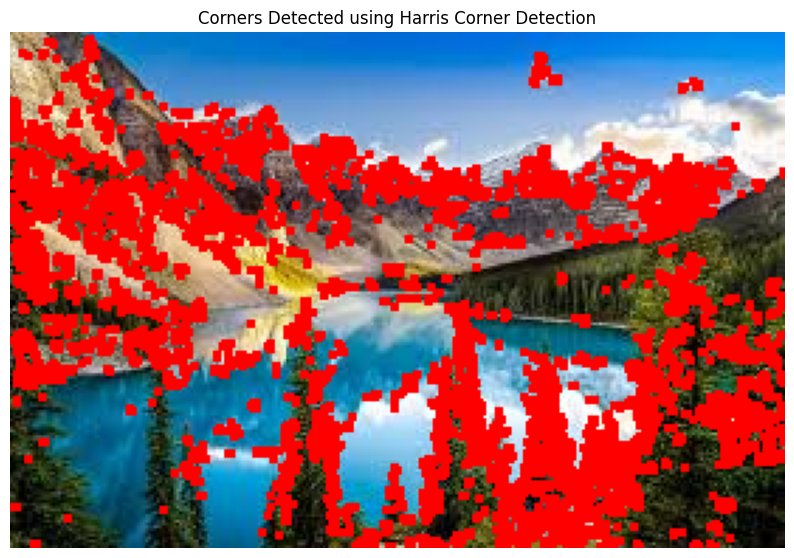

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image_path = '/content/images.jpg'
image = cv2.imread(image_path)

# Check if the image was loaded successfully
if image is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert the image to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Convert to float32 for cornerHarris function
    gray = np.float32(gray)

    # Apply Harris Corner Detection
    # Parameters: src, blockSize, ksize, k
    # blockSize: Size of a neighbourhood for corner detection
    # ksize: Aperture parameter for the Sobel operator
    # k: Harris detector free parameter in the equation
    dst = cv2.cornerHarris(gray, 2, 3, 0.04)

    # Result is dilated for marking the corners
    dst = cv2.dilate(dst, None)

    # Threshold for an optimal value, it may vary depending on the image
    # Mark the corners in red on the original image
    image[dst > 0.01 * dst.max()] = [0, 0, 255] # BGR format for OpenCV, so [0, 0, 255] is red

    # Convert BGR to RGB for displaying with matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Display the result
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.title('Corners Detected using Harris Corner Detection')
    plt.axis('off')
    plt.show()